In [1]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import pickle
import warnings
warnings.filterwarnings('ignore')

# Load dataset
df = pd.read_excel(r'C:\Users\KIIT0001\Downloads\Expanding_Tata_Steel_product_recommendation_datase-Genspark_AI_Sheets-20260528_1951.xlsx')
print(df.shape)
df.head()

(2071, 22)


,Product_ID,Category,Sub_Category,Product_Variant,Grade,Brand,Thickness_mm,Width_mm,Length_m,Weight_per_Unit_kg,...,Customer_Segment,Region,Manufacturing_Plant,Cost_per_Tonne_INR,Selling_Price_per_Tonne_INR,Sales_Volume_Tonnes,Revenue_INR,Profit_Margin_Pct,Inventory_Tonnes,Customer_Rating
0,TS-L-TMT-001,Long,TMT Bars,Tiscon SuperLinks 550D,Fe-550D,Tiscon,8.0,NaN,12.0,4.74,...,Retail,North,Jamshedpur,52000.0,62500.0,1850.0,115625000.0,0.168000,320.0,4.6
1,TS-L-TMT-002,Long,TMT Bars,Tiscon SuperLinks 550D,Fe-550D,Tiscon,10.0,NaN,12.0,7.40,...,Retail,North,Jamshedpur,51500.0,61800.0,2200.0,135960000.0,0.166667,410.0,4.7
2,TS-L-TMT-003,Long,TMT Bars,Tiscon 500D,Fe-500D,Tiscon,12.0,NaN,12.0,10.66,...,B2B,West,Kalinganagar,50800.0,60500.0,3100.0,187550000.0,0.160331,580.0,4.5
3,TS-L-TMT-004,Long,TMT Bars,Tiscon 500D,Fe-500D,Tiscon,16.0,NaN,12.0,18.96,...,B2B,West,Kalinganagar,50500.0,60000.0,2950.0,177000000.0,0.158333,510.0,4.5
4,TS-L-TMT-005,Long,TMT Bars,Tiscon Premium,Fe-600,Tiscon,20.0,NaN,12.0,29.62,...,Government,South,Jamshedpur,53000.0,64500.0,1620.0,104490000.0,0.178295,290.0,4.8


In [2]:
# Dropping unnecessary columns
df.drop(columns=[
    'Revenue_INR',
    'Cost_per_Tonne_INR',
    'Inventory_Tonnes',
    'Product_Variant',
    'Manufacturing_Plant',
    'Unit_of_Sale' 
], inplace=True)

print(df.shape)
print(df.columns.tolist())

(2071, 16)
['Product_ID', 'Category', 'Sub_Category', 'Grade', 'Brand', 'Thickness_mm', 'Width_mm', 'Length_m', 'Weight_per_Unit_kg', 'Application_Sector', 'Customer_Segment', 'Region', 'Selling_Price_per_Tonne_INR', 'Sales_Volume_Tonnes', 'Profit_Margin_Pct', 'Customer_Rating']


In [3]:
print(df.isnull().sum())

Product_ID                        1
Category                          1
Sub_Category                      1
Grade                             1
Brand                             1
Thickness_mm                    358
Width_mm                        871
Length_m                        994
Weight_per_Unit_kg             1201
Application_Sector                1
Customer_Segment                  1
Region                            1
Selling_Price_per_Tonne_INR       1
Sales_Volume_Tonnes               1
Profit_Margin_Pct                 1
Customer_Rating                   1
dtype: int64


In [4]:
#Dropping null row
df.dropna(subset=['Category'], inplace=True)
print(df.shape) 

(2070, 16)


In [5]:
#Dropping numerical values that we don't need for recommendation
df.drop(columns=[
    'Weight_per_Unit_kg',
    'Thickness_mm',
    'Width_mm',
    'Length_m'
], inplace=True)

print(df.shape) 
print(df.isnull().sum())

(2070, 12)
Product_ID                     0
Category                       0
Sub_Category                   0
Grade                          0
Brand                          0
Application_Sector             0
Customer_Segment               0
Region                         0
Selling_Price_per_Tonne_INR    0
Sales_Volume_Tonnes            0
Profit_Margin_Pct              0
Customer_Rating                0
dtype: int64


In [6]:
#Checking for the number of unique values in a column:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


Product_ID:
Product_ID
TS-L-TMT-001     1
TS-L-WR-2290     1
TS-F-CRC-2320    1
TS-L-STR-2319    1
TS-L-WR-2318     1
                ..
TS-F-ES-1615     1
TS-F-GP-1614     1
TS-F-HRC-1613    1
TS-L-RND-1612    1
TS-L-RND-3000    1
Name: count, Length: 2070, dtype: int64

Category:
Category
Long    1147
Flat     923
Name: count, dtype: int64

Sub_Category:
Sub_Category
TMT Bars             394
Structurals          317
Wire Rods            277
Hot Rolled Coils     192
Pipes & Tubes        157
Cold Rolled Coils    154
Galvanized           122
Rounds               119
Tinplate             118
Color Coated          84
Electrical Steel      78
Rails                 40
Hot Rolled            10
Cold Rolled            8
Name: count, dtype: int64

Grade:
Grade
IS-2062 E350      119
Fe-500D           118
IS-2062 E250      118
Fe-550D            79
Fe-415             79
                 ... 
RAL-3009 Red        1
RAL-5012 Blue       1
IS-1239 Medium      1
IF-Grade GI         1
RAL-9002 White   

In [7]:
# Apply to Application_Sector, Grade, Brand (Grouping values occuring <10 times as Others)
for col in ['Application_Sector', 'Grade', 'Brand']:
    counts = df[col].value_counts()
    rare = counts[counts < 10].index
    df[col] = df[col].replace(rare, 'Others')

In [8]:
for col in df.columns:
    print(f"\n{col}:")
    print(df[col].value_counts())


Product_ID:
Product_ID
TS-L-TMT-001     1
TS-L-WR-2290     1
TS-F-CRC-2320    1
TS-L-STR-2319    1
TS-L-WR-2318     1
                ..
TS-F-ES-1615     1
TS-F-GP-1614     1
TS-F-HRC-1613    1
TS-L-RND-1612    1
TS-L-RND-3000    1
Name: count, Length: 2070, dtype: int64

Category:
Category
Long    1147
Flat     923
Name: count, dtype: int64

Sub_Category:
Sub_Category
TMT Bars             394
Structurals          317
Wire Rods            277
Hot Rolled Coils     192
Pipes & Tubes        157
Cold Rolled Coils    154
Galvanized           122
Rounds               119
Tinplate             118
Color Coated          84
Electrical Steel      78
Rails                 40
Hot Rolled            10
Cold Rolled            8
Name: count, dtype: int64

Grade:
Grade
IS-2062 E350     119
Fe-500D          118
IS-2062 E250     118
Fe-415            79
Fe-550D           79
IS-12778          78
IS-277            77
IS-513 CR1        41
IS-1239           40
Fe-600            40
EN-24             40
EN-19 

In [9]:
#Label Encoding all Categorical Columns
categorical_cols = [
    'Category', 'Sub_Category', 'Grade', 
    'Brand', 'Application_Sector',
    'Customer_Segment', 'Region'
]

# Save each encoder separately for later use
encoders = {}
df_encoded = df.copy()

for col in categorical_cols:
    encoders[col] = LabelEncoder()
    df_encoded[col] = encoders[col].fit_transform(df[col])

# Verify encoding worked
print(df_encoded[categorical_cols].head())
print("\nData types after encoding:")
print(df_encoded.dtypes)

   Category  Sub_Category  Grade  Brand  Application_Sector  Customer_Segment  \
0         1            11     15     16                  10                 2   
1         1            11     15     16                  10                 2   
2         1            11     14     16                  20                 0   
3         1            11     14     16                  20                 0   
4         1            11     16     16                   8                 1   

   Region  
0       2  
1       2  
2       6  
3       6  
4       5  

Data types after encoding:
Product_ID                      object
Category                         int32
Sub_Category                     int32
Grade                            int32
Brand                            int32
Application_Sector               int32
Customer_Segment                 int32
Region                           int32
Selling_Price_per_Tonne_INR    float64
Sales_Volume_Tonnes            float64
Profit_Margin_Pct      

In [84]:
#Scaling Numerical and Categorical Columns
all_cols_to_scale = [
    'Category', 'Sub_Category', 'Grade', 'Brand',
    'Application_Sector', 'Customer_Segment', 'Region',
    'Selling_Price_per_Tonne_INR', 'Sales_Volume_Tonnes',
    'Profit_Margin_Pct', 'Customer_Rating'
]

scaler = MinMaxScaler()
df_encoded[all_cols_to_scale] = scaler.fit_transform(df_encoded[all_cols_to_scale])

df_encoded[all_cols_to_scale].describe().round(3)

,Category,Sub_Category,Grade,Brand,Application_Sector,Customer_Segment,Region,Selling_Price_per_Tonne_INR,Sales_Volume_Tonnes,Profit_Margin_Pct,Customer_Rating
count,2070.000,2070.000,2070.000,2070.000,2070.000,2070.000,2070.000,2070.000,2070.000,2070.000,2070.000
mean,0.554,0.641,0.485,0.711,0.468,0.202,0.641,0.142,0.352,0.410,0.680
std,0.497,0.291,0.270,0.278,0.290,0.358,0.343,0.159,0.207,0.142,0.194
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.462,0.286,0.562,0.231,0.000,0.333,0.061,0.207,0.312,0.556
50%,1.000,0.769,0.500,0.812,0.462,0.000,0.833,0.094,0.317,0.408,0.667
75%,1.000,0.846,0.690,0.938,0.718,0.500,1.000,0.133,0.480,0.504,0.778
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000


In [12]:
print(type(encoders['Region'].classes_))

<class 'numpy.ndarray'>


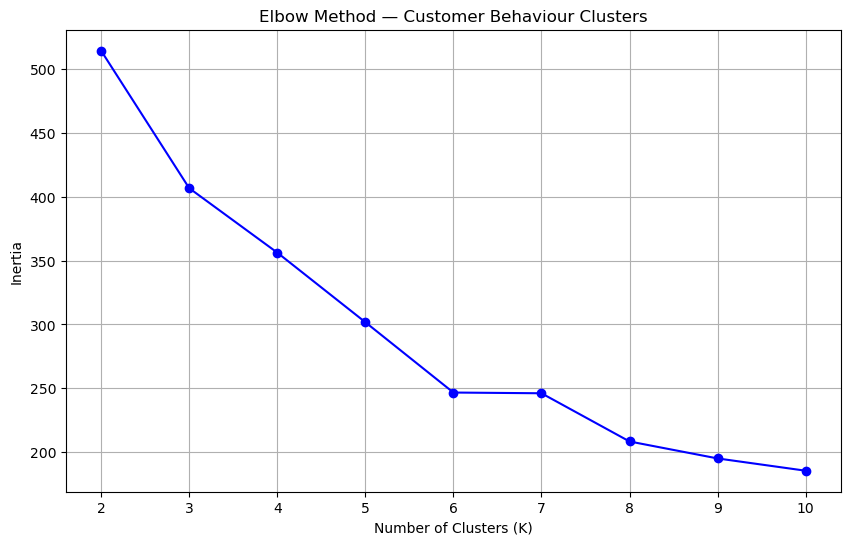

In [86]:
# Find optimal number of clusters
behaviour_features = [
    'Region',
    'Application_Sector',
    'Selling_Price_per_Tonne_INR',
    'Sales_Volume_Tonnes',
    'Sub_Category'
]

inertia = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_encoded[behaviour_features])
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method — Customer Behaviour Clusters')
plt.xticks(K)
plt.grid(True)
plt.show()

In [108]:
#KMeans
kmeans = KMeans(n_clusters=5, random_state=42)
df_encoded['Cluster'] = kmeans.fit_predict(df_encoded[behaviour_features])
df['Cluster'] = df_encoded['Cluster']

print(df['Cluster'].value_counts())

Cluster
2    708
3    436
1    332
0    298
4    296
Name: count, dtype: int64


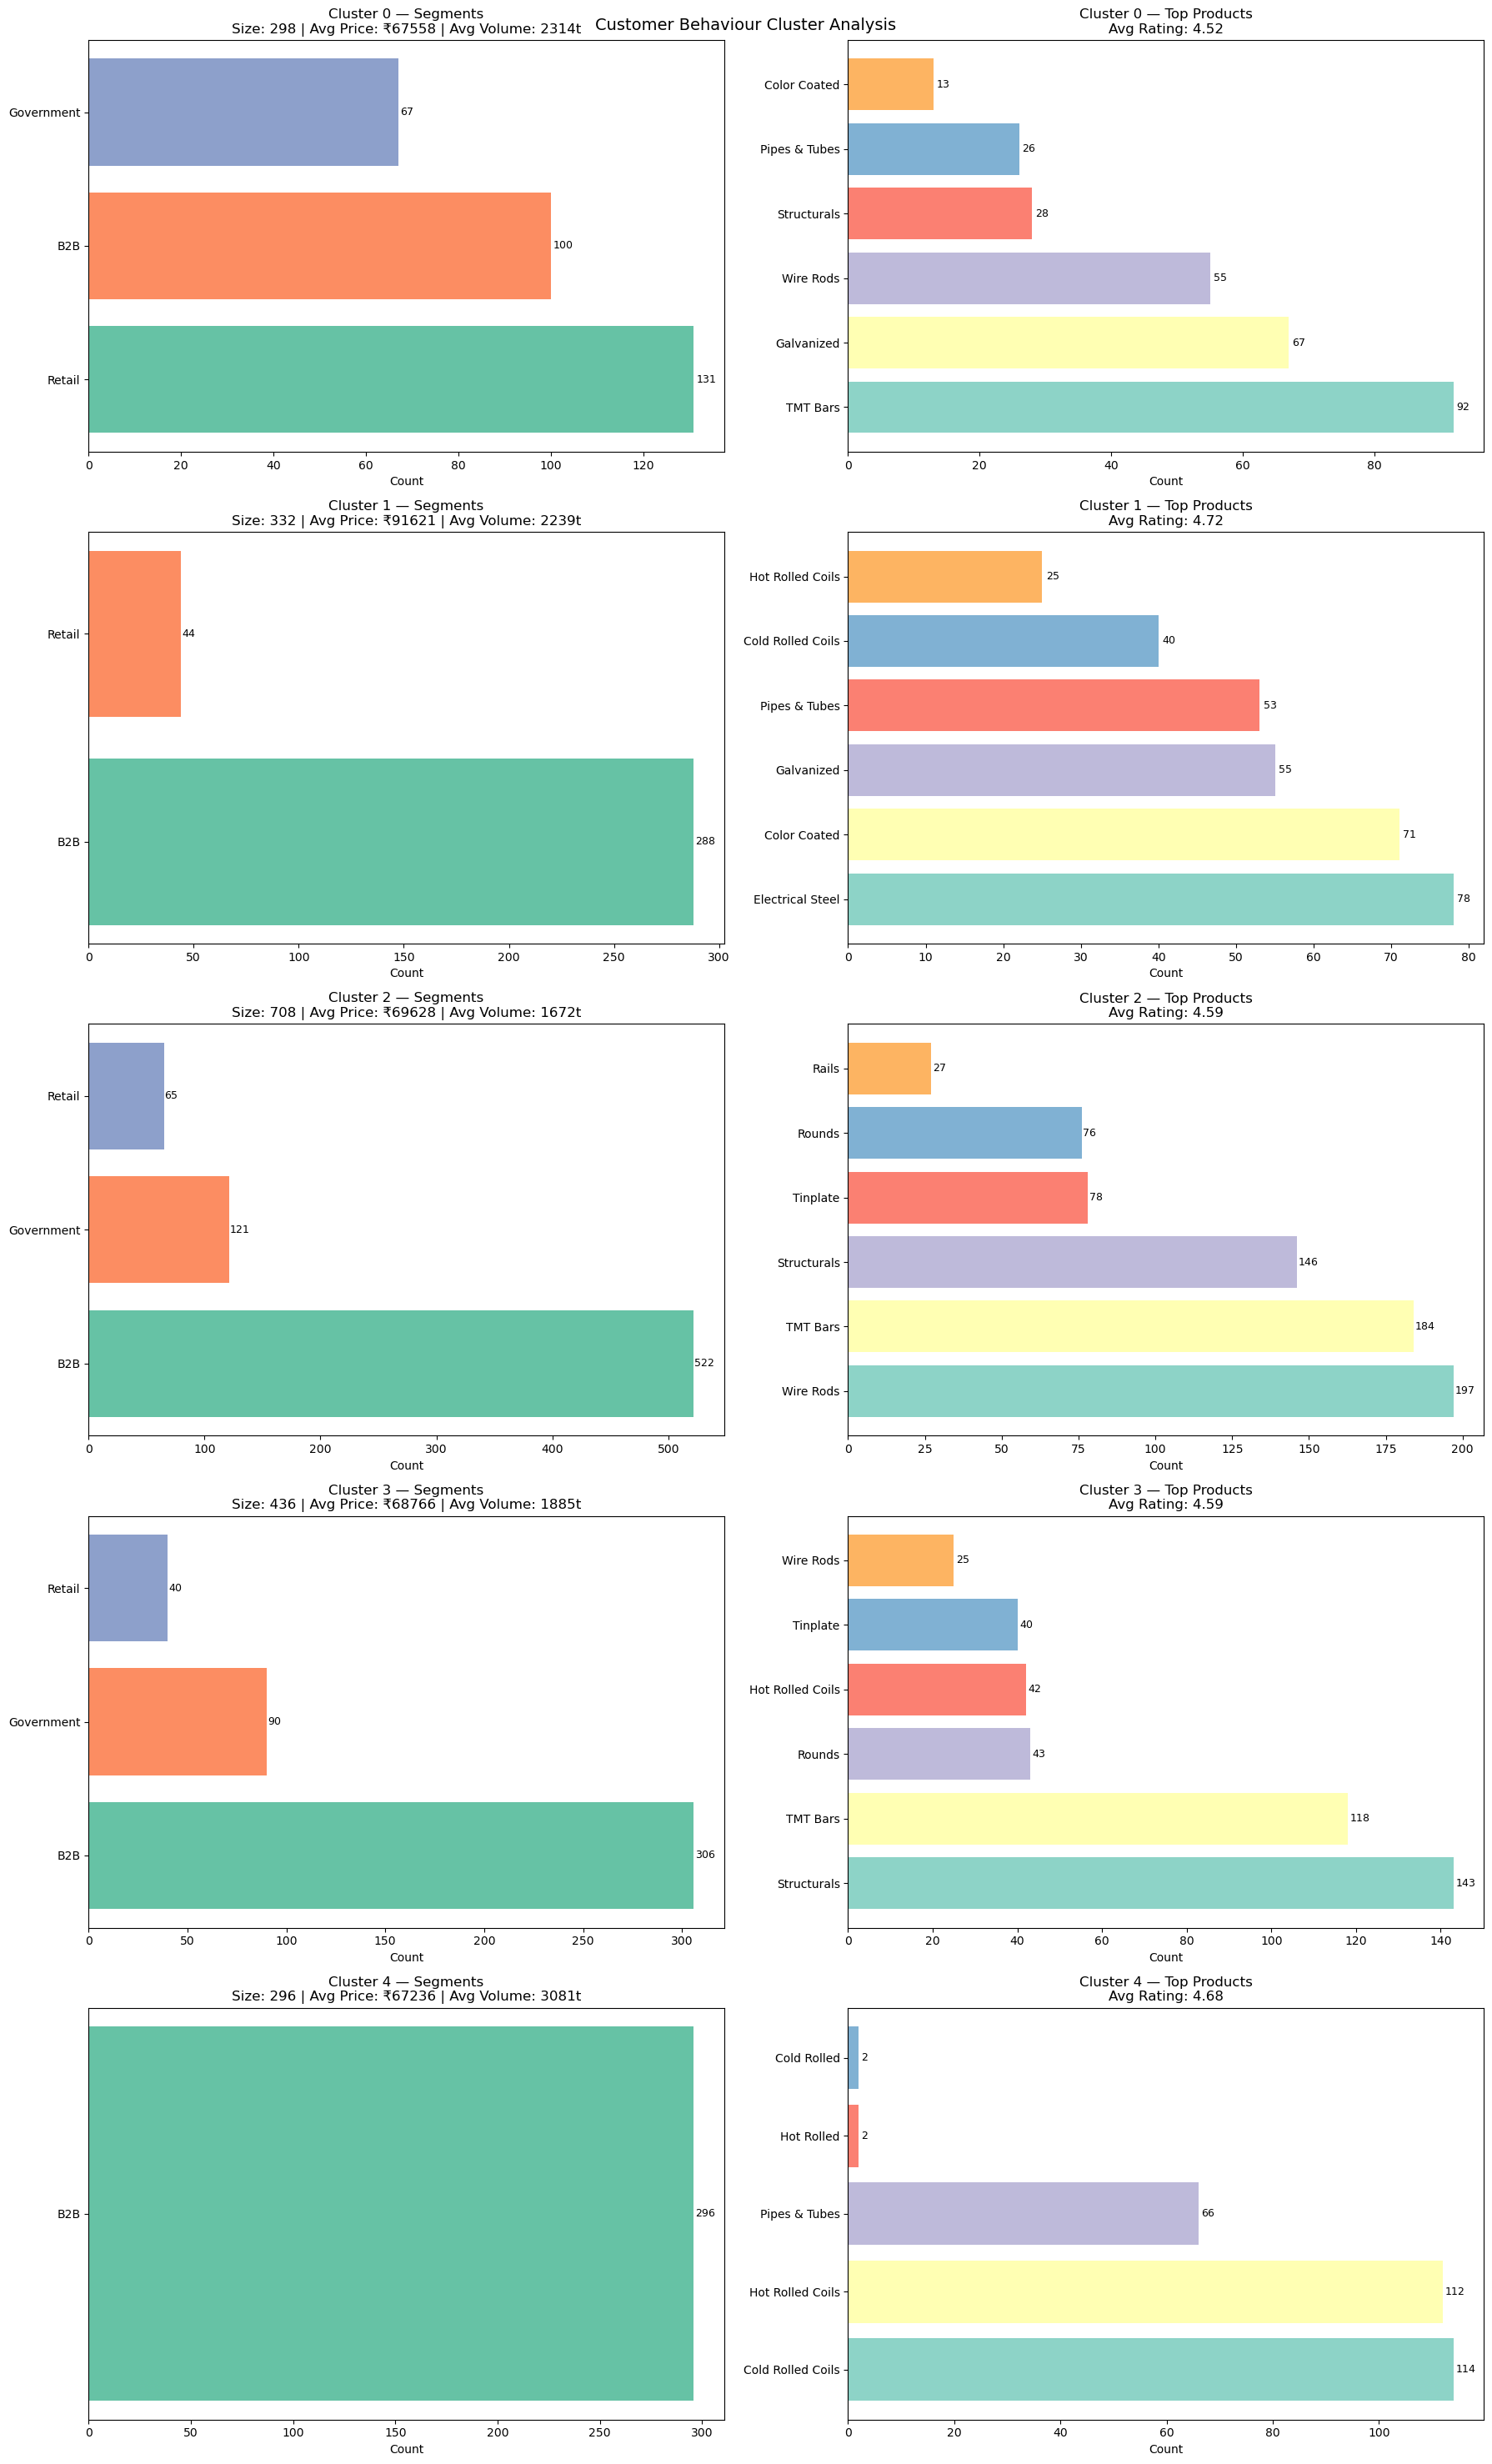

In [110]:
#Plotting what each cluster contains
fig, axes = plt.subplots(5, 2, figsize=(18, 30))

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    avg_price = cluster_data['Selling_Price_per_Tonne_INR'].mean()
    avg_volume = cluster_data['Sales_Volume_Tonnes'].mean()
    
    # Left plot: Customer Segment distribution
    segments = cluster_data['Customer_Segment'].value_counts()
    colors1 = sns.color_palette('Set2', len(segments))
    axes[i][0].barh(segments.index, segments.values, color=colors1)
    axes[i][0].set_title(f'Cluster {i} — Segments\n'
                         f'Size: {len(cluster_data)} | '
                         f'Avg Price: ₹{avg_price:.0f} | '
                         f'Avg Volume: {avg_volume:.0f}t')
    axes[i][0].set_xlabel('Count')
    for j, v in enumerate(segments.values):
        axes[i][0].text(v + 0.5, j, str(v), va='center', fontsize=9)

    # Right plot: Top Sub Categories
    top_subs = cluster_data['Sub_Category'].value_counts().head(6)
    colors2 = sns.color_palette('Set3', len(top_subs))
    axes[i][1].barh(top_subs.index, top_subs.values, color=colors2)
    axes[i][1].set_title(f'Cluster {i} — Top Products\n'
                         f'Avg Rating: {cluster_data["Customer_Rating"].mean():.2f}')
    axes[i][1].set_xlabel('Count')
    for j, v in enumerate(top_subs.values):
        axes[i][1].text(v + 0.5, j, str(v), va='center', fontsize=9)

plt.suptitle('Customer Behaviour Cluster Analysis', fontsize=14)
plt.tight_layout()
plt.show()

In [112]:
#Random Forest
customer_features = [
    'Customer_Segment',
    'Region',
    'Sales_Volume_Tonnes',
    'Application_Sector'
]

X = df_encoded[customer_features]
y = df_encoded['Cluster']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(f"Accuracy: {rf.score(X_test, y_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9928

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       0.98      1.00      0.99        65
           2       0.99      0.99      0.99       129
           3       0.99      1.00      0.99        98
           4       1.00      0.97      0.98        62

    accuracy                           0.99       414
   macro avg       0.99      0.99      0.99       414
weighted avg       0.99      0.99      0.99       414



In [114]:
feat_importance = pd.DataFrame({
    'Feature': customer_features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(feat_importance)

               Feature  Importance
3   Application_Sector    0.469381
1               Region    0.310586
2  Sales_Volume_Tonnes    0.187454
0     Customer_Segment    0.032579


In [156]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [5,6,7]
}

# Grid search with cross validation
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,        # use all CPU cores
    verbose=2         # shows progress
)

grid_search.fit(X_train, y_train)

# Best parameters
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score:   {grid_search.best_score_:.4f}")

# Train final model with best params
rf_tuned = grid_search.best_estimator_
y_pred_tuned = rf_tuned.predict(X_test)
print(f"\nTuned Accuracy: {rf_tuned.score(X_test, y_test):.4f}")
print(classification_report(y_test, y_pred_tuned))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV Score:   0.9958

Tuned Accuracy: 0.9928
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        60
           1       0.98      1.00      0.99        65
           2       0.99      0.99      0.99       129
           3       0.99      1.00      0.99        98
           4       1.00      0.97      0.98        62

    accuracy                           0.99       414
   macro avg       0.99      0.99      0.99       414
weighted avg       0.99      0.99      0.99       414

Tuned RF saved!


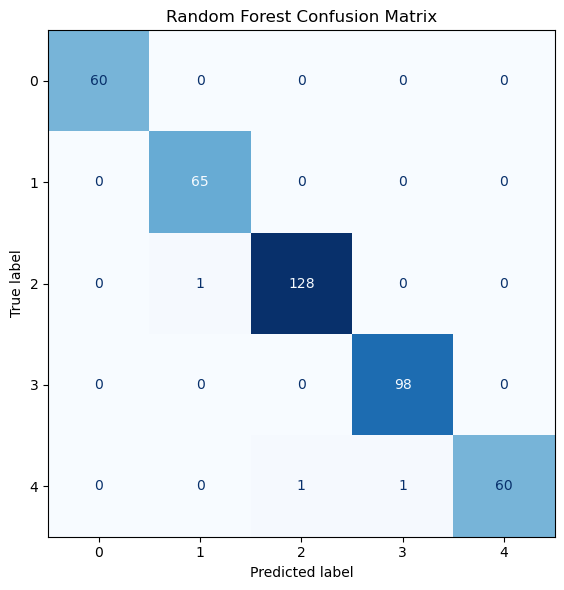

Accuracy: 0.9928


In [116]:
#Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
                               display_labels=[0,1,2,3,4])
fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

print(f"Accuracy: {rf.score(X_test, y_test):.4f}")

In [118]:
# Calculating Popularity Scores
df['popularity_score'] = (
    df_encoded['Customer_Rating'] * 0.5 +
    df_encoded['Sales_Volume_Tonnes'] * 0.5
)

df[['Sub_Category', 'Customer_Rating', 'Sales_Volume_Tonnes','popularity_score']].head(10)

,Sub_Category,Customer_Rating,Sales_Volume_Tonnes,popularity_score
0,TMT Bars,4.6,1850.0,0.483619
1,TMT Bars,4.7,2200.0,0.574860
2,TMT Bars,4.5,3100.0,0.555510
3,TMT Bars,4.5,2950.0,0.540217
4,TMT Bars,4.8,1620.0,0.571280
5,TMT Bars,4.6,1480.0,0.445895
6,TMT Bars,4.7,890.0,0.441295
7,TMT Bars,4.5,720.0,0.312851
8,TMT Bars,4.3,2680.0,0.401577
9,TMT Bars,4.2,3050.0,0.383746


In [124]:
#Creating a SubCategory x Features Table
subcat_df = df.groupby('Sub_Category').agg(
    Category=('Category', 'first'),
    Grade=('Grade', lambda x: x.mode()[0]),
    Brand=('Brand', lambda x: x.mode()[0]),
    Avg_Price=('Selling_Price_per_Tonne_INR', 'median'),  # ← median
    Avg_Margin=('Profit_Margin_Pct', 'median'),           # ← median
    Avg_Rating=('Customer_Rating', 'median')              # ← median
).reset_index()

print(subcat_df)

         Sub_Category Category         Grade             Brand  Avg_Price  \
0         Cold Rolled     Flat        Others     Tata Steelium    71100.0   
1   Cold Rolled Coils     Flat    IS-513 CR1     Tata Steelium    66500.0   
2        Color Coated     Flat      CC-Grade      Tata Pravesh    93650.0   
3    Electrical Steel     Flat     M27-Grade   Tata Steel CRGO   137250.0   
4          Galvanized     Flat        IS-277      Tata Shaktee    71400.0   
5          Hot Rolled     Flat        Others       Tata Astrum    66250.0   
6    Hot Rolled Coils     Flat      BQ-Grade    Tata Steel HRC    60850.0   
7       Pipes & Tubes     Flat       IS-1239        Tata Pipes    74000.0   
8               Rails     Long       IS-3443  Tata Steel Rails    69600.0   
9              Rounds     Long         EN-19     Tata Bearings    70600.0   
10        Structurals     Long  IS-2062 E350    Tata Structura    64100.0   
11           TMT Bars     Long       Fe-500D            Tiscon    62100.0   

In [140]:
#Encode categorical columns
subcat_encoded = subcat_df.copy()
subcat_cat_cols = ['Category', 'Grade', 'Brand']
subcat_encoders = {}

for col in subcat_cat_cols:
    subcat_encoders[col] = LabelEncoder()
    subcat_encoded[col] = subcat_encoders[col].fit_transform(subcat_df[col])

#Scale all features together
subcat_all_cols = ['Category', 'Grade', 'Brand',
                   'Avg_Price', 'Avg_Margin', 'Avg_Rating']

subcat_scaler = MinMaxScaler()
subcat_encoded[subcat_all_cols] = subcat_scaler.fit_transform(
    subcat_encoded[subcat_all_cols]
)

print("Subcat encoded and scaled:")
print(subcat_encoded[subcat_all_cols].describe().round(3))

#Build similarity matrix
from sklearn.metrics.pairwise import cosine_similarity

similarity_features = [
    'Category', 'Grade', 'Brand',
    'Avg_Price', 'Avg_Margin', 'Avg_Rating'
]

similarity_matrix = cosine_similarity(
    subcat_encoded[similarity_features].values
)

print(f"\nSimilarity matrix shape: {similarity_matrix.shape}")

Subcat encoded and scaled:
       Category   Grade   Brand  Avg_Price  Avg_Margin  Avg_Rating
count    14.000  14.000  14.000     14.000      14.000      14.000
mean      0.357   0.530   0.512      0.212       0.427       0.524
std       0.497   0.331   0.315      0.288       0.346       0.313
min       0.000   0.000   0.000      0.000       0.000       0.000
25%       0.000   0.271   0.271      0.050       0.174       0.333
50%       0.000   0.542   0.542      0.121       0.365       0.667
75%       1.000   0.812   0.729      0.164       0.611       0.667
max       1.000   1.000   1.000      1.000       1.000       1.000

Similarity matrix shape: (14, 14)


In [162]:
pd.DataFrame(similarity_matrix)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,1.000000,0.943550,0.432565,0.722584,0.852337,0.860966,0.691673,0.701048,0.560081,0.279916,0.641228,0.494818,0.837258,0.566856
1,0.943550,1.000000,0.667562,0.820799,0.952389,0.802775,0.782242,0.860221,0.580749,0.411059,0.659334,0.554011,0.941166,0.571045
2,0.432565,0.667562,1.000000,0.872490,0.748355,0.412305,0.668007,0.907927,0.301620,0.546161,0.357761,0.316099,0.839975,0.269812
3,0.722584,0.820799,0.872490,1.000000,0.885233,0.709505,0.629495,0.919645,0.445866,0.489308,0.471848,0.353036,0.958526,0.347966
4,0.852337,0.952389,0.748355,0.885233,1.000000,0.788061,0.618454,0.903058,0.600240,0.467637,0.597834,0.513971,0.964888,0.456819
5,0.860966,0.802775,0.412305,0.709505,0.788061,1.000000,0.469975,0.743384,0.408063,0.302983,0.436340,0.192648,0.737562,0.280847
6,0.691673,0.782242,0.668007,0.629495,0.618454,0.469975,1.000000,0.721057,0.292290,0.347708,0.527868,0.438908,0.729818,0.566991
7,0.701048,0.860221,0.907927,0.919645,0.903058,0.743384,0.721057,1.000000,0.405833,0.537871,0.467588,0.334215,0.932267,0.336703
8,0.560081,0.580749,0.301620,0.445866,0.600240,0.408063,0.292290,0.405833,1.000000,0.803179,0.952535,0.930996,0.545791,0.877948
9,0.279916,0.411059,0.546161,0.489308,0.467637,0.302983,0.347708,0.537871,0.803179,1.000000,0.804775,0.733203,0.485948,0.723871


In [146]:
def recommend_popular(customer_segment, region, 
                      application_sector, sales_volume, n=5):
    
    #Encode inputs
    seg_encoded = encoders['Customer_Segment'].transform([customer_segment])[0]
    reg_encoded = encoders['Region'].transform([region])[0]
    app_encoded = encoders['Application_Sector'].transform([application_sector])[0]
    
    input_df = pd.DataFrame([[
        0,            # Category
        0,            # Sub_Category
        0,            # Grade
        0,            # Brand
        app_encoded,  # Application_Sector
        seg_encoded,  # Customer_Segment
        reg_encoded,  # Region
        0,            # Selling_Price
        sales_volume, # Sales_Volume_Tonnes
        0,            # Profit_Margin
        0             # Customer_Rating
    ]], columns=all_cols_to_scale)
    
    #Scale using main scaler
    input_scaled = scaler.transform(input_df)
    input_scaled_df = pd.DataFrame(input_scaled, columns=all_cols_to_scale)
    
    #Extract RF features in correct order
    customer_input = input_scaled_df[customer_features]
    
    #RF predicts cluster
    predicted_cluster = rf.predict(customer_input)[0]
    print(f"Predicted Cluster: {predicted_cluster}")
    
    #Filter by cluster + segment
    cluster_products = df[
        (df['Cluster'] == predicted_cluster) &
        (df['Customer_Segment'] == customer_segment)
    ]
    
    if len(cluster_products) < n:
        cluster_products = df[df['Cluster'] == predicted_cluster]
    
    #Sort by popularity
    recommendations = cluster_products.sort_values(
        'popularity_score', ascending=False
    ).drop_duplicates(subset=['Sub_Category']).head(n)
    
    return recommendations[['Sub_Category', 'Brand', 'Grade',
                             'Selling_Price_per_Tonne_INR',
                             'Customer_Rating', 'popularity_score']]


def recommend_similar(selected_subcategory, n=5):
    
    idx = subcat_df[subcat_df['Sub_Category'] == selected_subcategory].index[0]
    scores = list(enumerate(similarity_matrix[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    scores = scores[1:n+1]
    
    similar_subcats = [subcat_df.iloc[i[0]]['Sub_Category'] for i in scores]
    similar_products = df[df['Sub_Category'].isin(similar_subcats)]
    
    return similar_products.sort_values(
        'popularity_score', ascending=False
    ).drop_duplicates(subset=['Sub_Category'])[['Sub_Category', 'Brand', 
                                                 'Grade', 'Selling_Price_per_Tonne_INR',
                                                 'Customer_Rating']]


def hybrid_recommend(customer_segment, region,
                     application_sector, sales_volume,
                     selected_subcategory=None, n=5):
    
    print("=" * 50)
    print("LAYER 1+2: Popularity Based Recommendations")
    print("=" * 50)
    popular = recommend_popular(
        customer_segment, region,
        application_sector, sales_volume, n
    )
    print(popular.to_string())
    
    if selected_subcategory:
        print(f"\n{'='*50}")
        print(f"LAYER 3: Similar to '{selected_subcategory}'")
        print("=" * 50)
        similar = recommend_similar(selected_subcategory, n)
        print(similar.to_string())
        return popular, similar
    
    return popular, None

In [148]:
# Test Layer 1+2 only
hybrid_recommend(
    customer_segment='B2B',
    region='West',
    application_sector='Automotive',
    sales_volume=2000
)

LAYER 1+2: Popularity Based Recommendations
Predicted Cluster: 4
           Sub_Category           Brand         Grade  Selling_Price_per_Tonne_INR  Customer_Rating  popularity_score
1259      Pipes & Tubes  Tata Structura       YST-310                      72800.0              4.8          0.885309
1730   Hot Rolled Coils  Tata Steel HRC  IS-2062 E350                      57100.0              4.7          0.834444
831   Cold Rolled Coils   Tata Steelium    IS-513 CR3                      68000.0              4.9          0.807300
40          Cold Rolled   Tata Steelium    IS-513 CR1                      68500.0              4.7          0.743090
30           Hot Rolled     Tata Astrum  IS-2062 E250                      62500.0              4.6          0.723219


(           Sub_Category           Brand         Grade  \
 1259      Pipes & Tubes  Tata Structura       YST-310   
 1730   Hot Rolled Coils  Tata Steel HRC  IS-2062 E350   
 831   Cold Rolled Coils   Tata Steelium    IS-513 CR3   
 40          Cold Rolled   Tata Steelium    IS-513 CR1   
 30           Hot Rolled     Tata Astrum  IS-2062 E250   
 
       Selling_Price_per_Tonne_INR  Customer_Rating  popularity_score  
 1259                      72800.0              4.8          0.885309  
 1730                      57100.0              4.7          0.834444  
 831                       68000.0              4.9          0.807300  
 40                        68500.0              4.7          0.743090  
 30                        62500.0              4.6          0.723219  ,
 None)

In [154]:
hybrid_recommend(
    customer_segment='B2B',
    region='East',
    application_sector='Others',
    sales_volume=2000,
    selected_subcategory='Cold Rolled Coils'
)

LAYER 1+2: Popularity Based Recommendations
Predicted Cluster: 0
          Sub_Category           Brand       Grade  Selling_Price_per_Tonne_INR  Customer_Rating  popularity_score
1500     Pipes & Tubes      Tata Pipes     IS-1239                      70200.0              4.8          0.821382
51          Galvanized    Tata Shaktee      Others                      78000.0              4.7          0.743090
34          Hot Rolled     Tata Astrum      Others                      65500.0              4.7          0.702307
58        Color Coated          Others      Others                      96500.0              4.8          0.628376
1683  Hot Rolled Coils  Tata Steel HRC  API-5L X65                      69100.0              4.9          0.594719

LAYER 3: Similar to 'Cold Rolled Coils'
          Sub_Category             Brand       Grade  Selling_Price_per_Tonne_INR  Customer_Rating
50          Galvanized      Tata Shaktee      Others                      76800.0              4.8
1259  

(          Sub_Category           Brand       Grade  \
 1500     Pipes & Tubes      Tata Pipes     IS-1239   
 51          Galvanized    Tata Shaktee      Others   
 34          Hot Rolled     Tata Astrum      Others   
 58        Color Coated          Others      Others   
 1683  Hot Rolled Coils  Tata Steel HRC  API-5L X65   
 
       Selling_Price_per_Tonne_INR  Customer_Rating  popularity_score  
 1500                      70200.0              4.8          0.821382  
 51                        78000.0              4.7          0.743090  
 34                        65500.0              4.7          0.702307  
 58                        96500.0              4.8          0.628376  
 1683                      69100.0              4.9          0.594719  ,
           Sub_Category             Brand       Grade  \
 50          Galvanized      Tata Shaktee      Others   
 1259     Pipes & Tubes    Tata Structura     YST-310   
 41         Cold Rolled     Tata Steelium  IS-513 CR2   
 431   

In [138]:
pickle.dump(df, open('products.pkl', 'wb'))
pickle.dump(kmeans, open('kmeans.pkl', 'wb'))
pickle.dump(rf, open('random_forest.pkl', 'wb'))
pickle.dump(encoders, open('encoders.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))
pickle.dump(similarity_matrix, open('similarity_matrix.pkl', 'wb'))
pickle.dump(subcat_df, open('subcat_df.pkl', 'wb'))
pickle.dump(subcat_encoders, open('subcat_encoders.pkl', 'wb'))
pickle.dump(subcat_scaler, open('subcat_scaler.pkl', 'wb'))
print("All saved!")

All saved!
